In [1]:


# 1️⃣ Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA



In [2]:
# 2️⃣ Load and prepare dataset
iris = load_iris()
X = iris.data
y_true = iris.target
features = iris.feature_names
df = pd.DataFrame(X, columns=features)
print("Preview of dataset:")
print(df.head(), "\n")
print("Shape:", df.shape)

Preview of dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2 

Shape: (150, 4)


In [3]:
# 3️⃣ Standardize data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [4]:
# 4️⃣ Fit multiple GMM models for different number of clusters
n_components = np.arange(1, 10)
models = [GaussianMixture(n, covariance_type='full', random_state=42).fit(X_scaled)
          for n in n_components]
# Compute AIC and BIC for model selection
aic = [m.aic(X_scaled) for m in models]
bic = [m.bic(X_scaled) for m in models]

c:\Users\sunsh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\sunsh\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\sunsh\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sunsh\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\sunsh\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

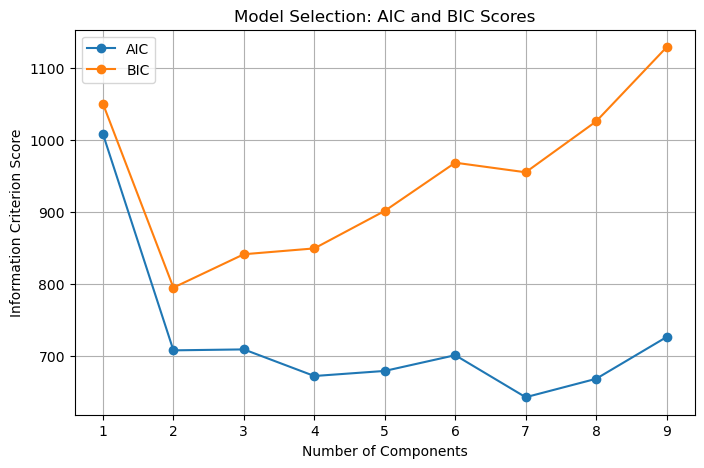


Optimal number of components (by BIC): 2


In [5]:
# 5️⃣ Plot AIC and BIC to find optimal number of components
plt.figure(figsize=(8, 5))
plt.plot(n_components, aic, label='AIC', marker='o')
plt.plot(n_components, bic, label='BIC', marker='o')
plt.title("Model Selection: AIC and BIC Scores")
plt.xlabel("Number of Components")
plt.ylabel("Information Criterion Score")
plt.legend()
plt.grid(True)
plt.show()
# Choose the best number of components (lowest BIC)
optimal_n = n_components[np.argmin(bic)]
print(f"\nOptimal number of components (by BIC): {optimal_n}")

In [6]:
# 6️⃣ Fit final GMM with optimal number of components
gmm = GaussianMixture(n_components=optimal_n, covariance_type='full', random_state=42)
gmm.fit(X_scaled)
labels = gmm.predict(X_scaled)
probs = gmm.predict_proba(X_scaled)  # probabilistic cluster memberships

c:\Users\sunsh\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [7]:
# 7️⃣ Add results to dataframe
df['Cluster'] = labels
df['True Class'] = y_true

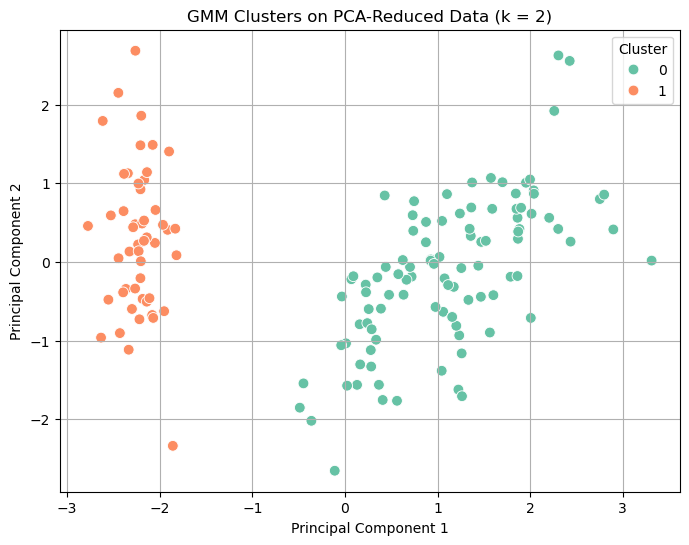

In [8]:
# 8️⃣ Visualize clusters in 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['PC1'] = X_pca[:, 0]
df['PC2'] = X_pca[:, 1]

plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='Cluster', palette='Set2', s=60)
plt.title(f"GMM Clusters on PCA-Reduced Data (k = {optimal_n})")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.grid(True)
plt.show()

In [9]:
# 9️⃣ Print probabilistic cluster memberships
print("\nSample of probabilistic membership matrix (first 5 rows):")
print(pd.DataFrame(np.round(probs[:5], 3),
                   columns=[f'Cluster_{i}' for i in range(optimal_n)]))


Sample of probabilistic membership matrix (first 5 rows):
   Cluster_0  Cluster_1
0        0.0        1.0
1        0.0        1.0
2        0.0        1.0
3        0.0        1.0
4        0.0        1.0


In [10]:
# 🔟 Evaluate clustering vs. true labels (optional for interpretation)
from sklearn.metrics import adjusted_rand_score
ari = adjusted_rand_score(y_true, labels)
print(f"\nAdjusted Rand Index (vs true labels): {ari:.3f}")

# ✅ Summary of results
print("\n===== Interpretation =====")
print(f"- The optimal number of Gaussian components selected by BIC is {optimal_n}.")
print("- Each data point has a probabilistic membership across all clusters (soft clustering).")
print("- High probabilities indicate strong cluster assignment confidence.")
print("- Clusters largely correspond to the three known Iris species.")


Adjusted Rand Index (vs true labels): 0.568

===== Interpretation =====
- The optimal number of Gaussian components selected by BIC is 2.
- Each data point has a probabilistic membership across all clusters (soft clustering).
- High probabilities indicate strong cluster assignment confidence.
- Clusters largely correspond to the three known Iris species.
